In [1]:
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime

## annual dust AOD and dust burden

In [5]:
ds10_2d = xr.open_dataset('/data/shared_data/data_from_others/Longeli_CESM/CESM2_MAM10-Part02-Meteo_and_2D_dust_quantities.nc')
ds4_2d  = xr.open_dataset('/data/shared_data/data_from_others/Longeli_CESM/CESM2_MAM04-Part02-Meteo_and_2D_dust_quantities.nc')

### annual mean daytime

In [6]:
aod10 = ds10_2d["AODDUST"].mean("time")
aod4  = ds4_2d["AODDUST"].mean("time")
daod  = aod10 - aod4

bur10 = ds10_2d["BURDENDUST"].mean("time") * 1e3   # g m^-2
bur4  = ds4_2d["BURDENDUST"].mean("time") * 1e3
dbur  = bur10 - bur4

lon, lat = ds10_2d["lon"], ds10_2d["lat"]
proj = ccrs.Robinson(central_longitude=0)
dpi = 100

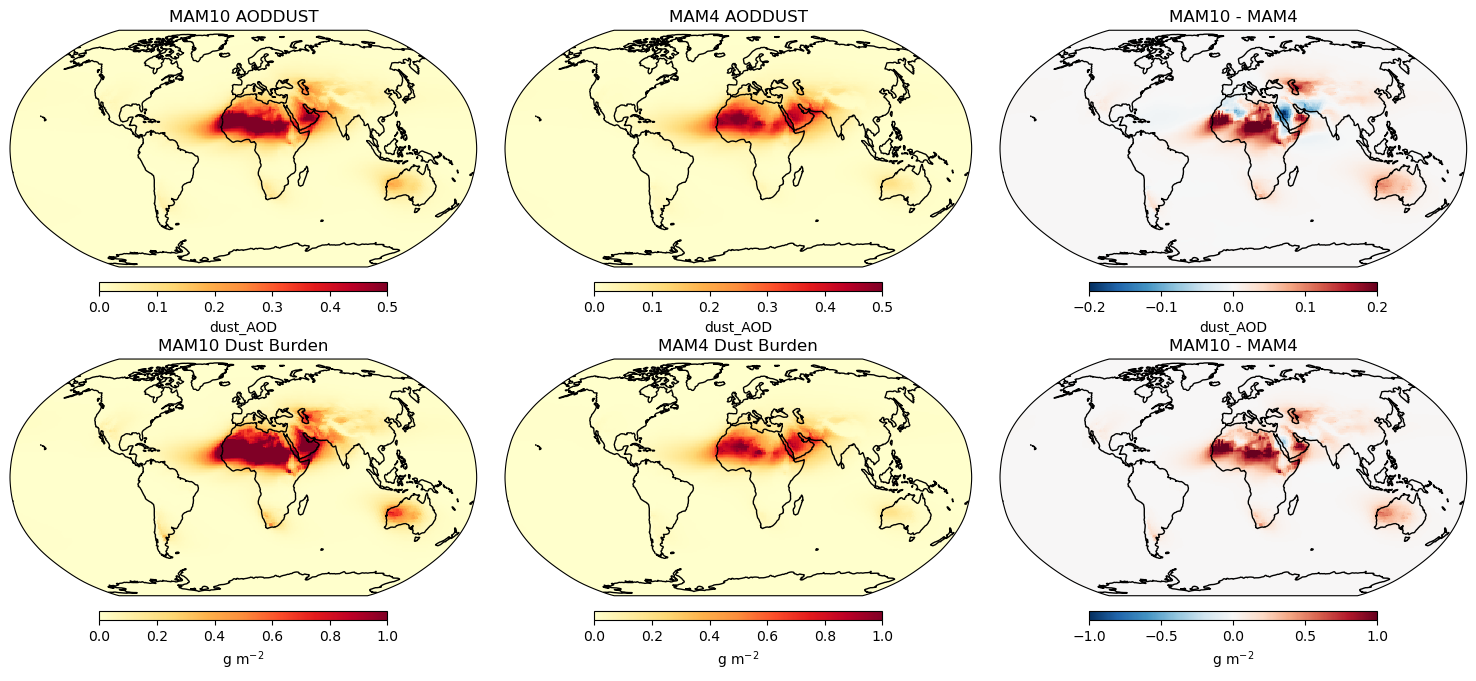

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.8), subplot_kw={"projection": proj}, dpi=dpi)

for ax in axes.ravel():
    ax.coastlines(linewidth=1, resolution="110m")
    ax.set_global()

plot_data = [
    (aod10, "MAM10 AODDUST", "YlOrRd", 0, 0.5, "dust_AOD"),
    (aod4 , "MAM4 AODDUST",  "YlOrRd", 0, 0.5, "dust_AOD"),
    (daod , "MAM10 - MAM4",  "RdBu_r", -0.2, 0.2, "dust_AOD"),
    (bur10, "MAM10 Dust Burden", "YlOrRd", 0, 1, "g m$^{-2}$"),
    (bur4 , "MAM4 Dust Burden",  "YlOrRd", 0, 1, "g m$^{-2}$"),
    (dbur , "MAM10 - MAM4",      "RdBu_r", -1, 1, "g m$^{-2}$")
]

for ax, (data, title, cmap, vmin, vmax, cblab) in zip(axes.ravel(), plot_data):
    im = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.6, aspect=30)
    cb.set_label(cblab)

plt.tight_layout()
plt.show()

### annual mean daytime and nighttime

In [8]:
aod10 = ds10_2d["AODDUSTdn"].mean("time")
aod4  = ds4_2d["AODDUSTdn"].mean("time")
daod  = aod10 - aod4

bur10 = ds10_2d["BURDENDUSTdn"].mean("time") * 1e3   # g m^-2
bur4  = ds4_2d["BURDENDUSTdn"].mean("time") * 1e3
dbur  = bur10 - bur4

lon, lat = ds10_2d["lon"], ds10_2d["lat"]
proj = ccrs.Robinson(central_longitude=0)

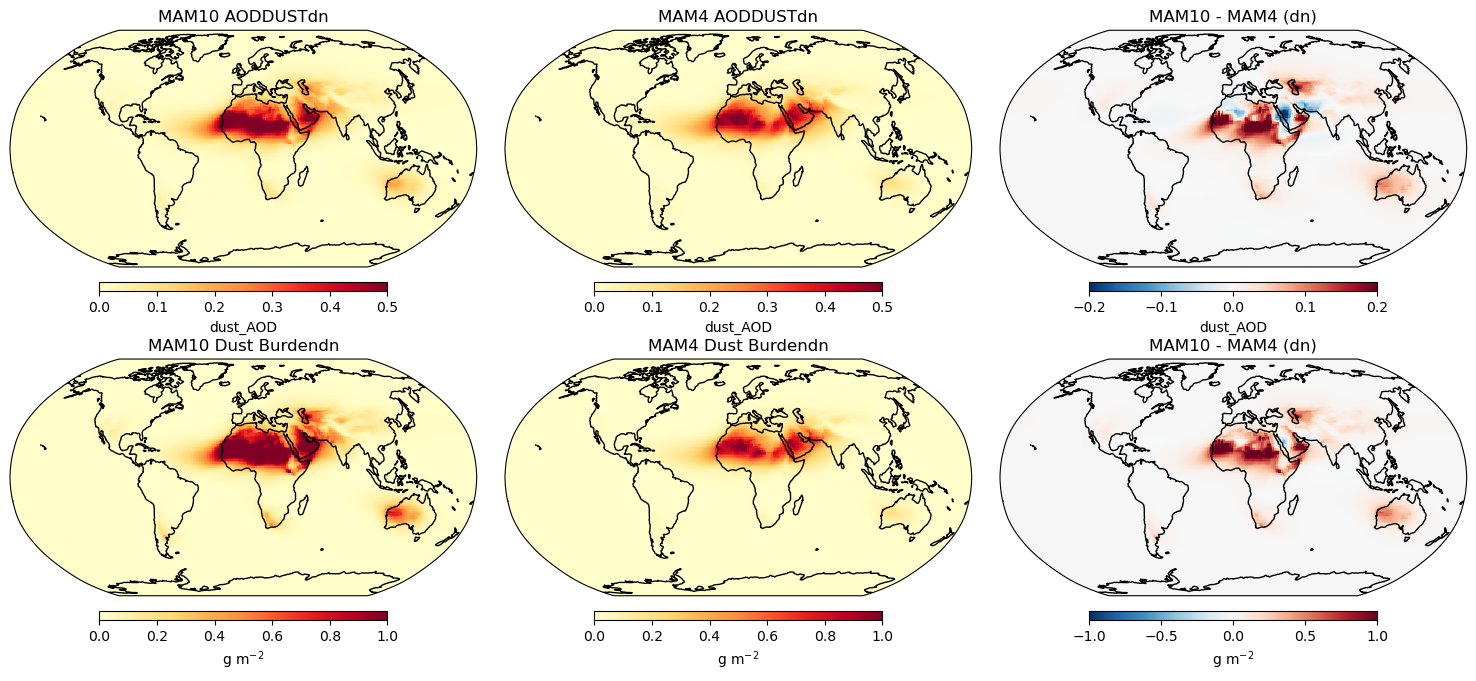

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.8), subplot_kw={"projection": proj}, dpi=dpi)

for ax in axes.ravel():
    ax.coastlines(linewidth=1, resolution="110m")
    ax.set_global()

plot_data = [
    (aod10, "MAM10 AODDUSTdn", "YlOrRd", 0, 0.5, "dust_AOD"),
    (aod4 , "MAM4 AODDUSTdn",  "YlOrRd", 0, 0.5, "dust_AOD"),
    (daod , "MAM10 - MAM4 (dn)",  "RdBu_r", -0.2, 0.2, "dust_AOD"),
    (bur10, "MAM10 Dust Burdendn", "YlOrRd", 0, 1, "g m$^{-2}$"),
    (bur4 , "MAM4 Dust Burdendn",  "YlOrRd", 0, 1, "g m$^{-2}$"),
    (dbur , "MAM10 - MAM4 (dn)",      "RdBu_r", -1, 1, "g m$^{-2}$")
]

for ax, (data, title, cmap, vmin, vmax, cblab) in zip(axes.ravel(), plot_data):
    im = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.6, aspect=30)
    cb.set_label(cblab)

plt.tight_layout()
plt.show()

## Dust Profile

In [10]:
ds10_mode13 = xr.open_dataset('/data/shared_data/data_from_others/Longeli_CESM/CESM2_MAM10-Part02-3D_dust_quantities_mode01-03.nc')
ds10_mode45 = xr.open_dataset('/data/shared_data/data_from_others/Longeli_CESM/CESM2_MAM10-Part02-3D_dust_quantities_mode04-05.nc')
ds10_3d = xr.merge([ds10_mode13, ds10_mode45])
ds4_3d  = xr.open_dataset('/data/shared_data/data_from_others/Longeli_CESM/CESM2_MAM04-Part02-3D_dust_quantities.nc')

In [11]:
cmap10 = plt.get_cmap("magma_r")
cmap4  = plt.get_cmap("ocean")
c10 = [cmap10(i) for i in np.linspace(0.15, 0.9, len(vars10))]
c4  = [cmap4(i)  for i in np.linspace(0.1, 0.9, len(vars4))]

NameError: name 'vars10' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

vars10 = ['atm_dst_01','atm_dst_02','atm_dst_03','atm_dst_04','atm_dst_05']
vars4  = ['atm_dst_01','atm_dst_02','atm_dst_03']
vars34 = ['atm_dst_01','atm_dst_02','atm_dst_03']
lev = ds10_3d['lev']

seasons = [None, 'DJF', 'MAM', 'JJA', 'SON']
row_titles = ['Annual', 'DJF', 'MAM', 'JJA', 'SON']

def sel_season(ds, s):
    return ds if s is None else ds.sel(time=ds['time'].dt.season == s)

fig, ax = plt.subplots(5, 3, figsize=(8, 20), dpi=dpi, sharey=True)

for i, (ssn, rttl) in enumerate(zip(seasons, row_titles)):
    d10 = sel_season(ds10_3d, ssn)
    d4  = sel_season(ds4_3d,  ssn)

    prof10 = {v: d10[v].mean(['time','lat','lon']) * 1000 for v in vars10}
    prof4  = {v: d4[v].mean(['time','lat','lon']) * 1000 for v in vars4}
    tot10  = sum(prof10[v] for v in vars10)
    tot4   = sum(prof4[v] for v in vars4)
    diff   = {v: prof10[v] - prof4[v] for v in vars34}
    dtot   = tot10 - tot4

    # ===== col 0: all modes =====
    for v, c in zip(vars10, c10):
        ax[i,0].plot(prof10[v], lev, color=c, lw=1.2, label=f'MAM10 {v[-2:]}')
    for v, c in zip(vars4, c4):
        ax[i,0].plot(prof4[v], lev, color=c, lw=2, ls='--', label=f'MAM4 {v[-2:]}')
    ax[i,0].invert_yaxis()
    ax[i,0].set_xlabel('Dust conc. (g kg$^{-1}$)')
    ax[i,0].set_ylabel(f'{rttl}\nPressure (hPa)')
    ax[i,0].set_title('Mode profiles' if i == 0 else '')
    ax[i,0].grid(alpha=0.3, ls='--')
    if i == 0: ax[i,0].legend(fontsize=8)

    # ===== col 1: total =====
    ax[i,1].plot(tot10, lev, color='firebrick', lw=2, label='MAM10 total (01-05)')
    ax[i,1].plot(tot4,  lev, color='navy', lw=2, ls='--', label='MAM4 total (01-03)')
    ax[i,1].invert_yaxis()
    ax[i,1].set_xlabel('Dust conc. (g kg$^{-1}$)')
    ax[i,1].set_ylabel('Pressure (hPa)')
    ax[i,1].set_title('Total profile' if i == 0 else '')
    ax[i,1].grid(alpha=0.3, ls='--')
    if i == 0: ax[i,1].legend(fontsize=8)

    # ===== col 2: differences =====
    for v, c in zip(vars34, c10[:3]):
        ax[i,2].plot(diff[v], lev, color=c, lw=2, label=f'{v[-2:]} diff')
    ax[i,2].plot(dtot, lev, color='k', lw=2.5, label='Total diff')
    ax[i,2].invert_yaxis()
    ax[i,2].set_xlabel('Dust conc. diff. (g kg$^{-1}$)')
    ax[i,2].set_ylabel('Pressure (hPa)')
    ax[i,2].set_title('MAM10 - MAM4' if i == 0 else '')
    ax[i,2].grid(alpha=0.3, ls='--')
    ax[i,2].axvline(0, color='gray', lw=1)
    if i == 0: ax[i,2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
rows = ["total","atm_dst_01","atm_dst_02","atm_dst_03"]

lon_s = ((lon + 180) % 360) - 180
idx = np.argsort(lon_s.values if hasattr(lon_s, "values") else lon_s)
lon_s = lon_s[idx]

def getf(r):
    a10 = sum(ds10_3d[v] for v in vars10)*1000 if r=="total" else ds10_3d[r]*1000
    a4  = sum(ds4_3d[v]  for v in vars4 )*1000 if r=="total" else ds4_3d[r]*1000
    lon10 = a10.mean(["time","lat"]).values[:, idx]
    lon4  = a4.mean(["time","lat"]).values[:, idx]
    dlon  = lon10 - lon4
    lat10 = a10.mean(["time","lon"]).values
    lat4  = a4.mean(["time","lon"]).values
    dlat  = lat10 - lat4
    return lon10, lon4, dlon, lat10, lat4, dlat

fig, ax = plt.subplots(4, 6, figsize=(17, 10), dpi=dpi, constrained_layout=True)
cts = ["MAM10","MAM4","Diff (MAM10 - MAM4)","MAM10","MAM4","Diff (MAM10 - MAM4)"]
for j, t in enumerate(cts):
    ax[0, j].set_title(t, fontsize=10)

for i, r in enumerate(rows):
    lon10, lon4, dlon, lat10, lat4, dlat = getf(r)
    va = 0.0002
    vd = 0.0001
    arrs = [
        (lon_s, lev, lon10, "YlOrRd", 0, va),
        (lon_s, lev, lon4,  "YlOrRd", 0, va),
        (lon_s, lev, dlon,  "RdBu_r",  -vd, vd),
        (lat,   lev, lat10, "YlOrRd", 0, va),
        (lat,   lev, lat4,  "YlOrRd", 0, va),
        (lat,   lev, dlat,  "RdBu_r",  -vd, vd)
    ]
    for j, (x, y, z, cmap, vmin, vmax) in enumerate(arrs):
        im = ax[i, j].pcolormesh(x, y, z, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax[i, j].invert_yaxis()
        ax[i, j].grid(alpha=.2, ls="--")
        ax[i, j].set_xlabel("Longitude" if j < 3 else "Latitude")
        ax[i, j].set_ylabel(f"{r}\nPressure (hPa)" if j == 0 else "Pressure (hPa)")
        plt.colorbar(im, ax=ax[i, j], orientation="horizontal", pad=.04, shrink=.8).set_label(
            "Dust conc. (g kg$^{-1}$)" if j not in [2, 5] else "Difference (g kg$^{-1}$)", fontsize=8
        )
# plt.tight_layout()
plt.show()

## Cloud Fraction

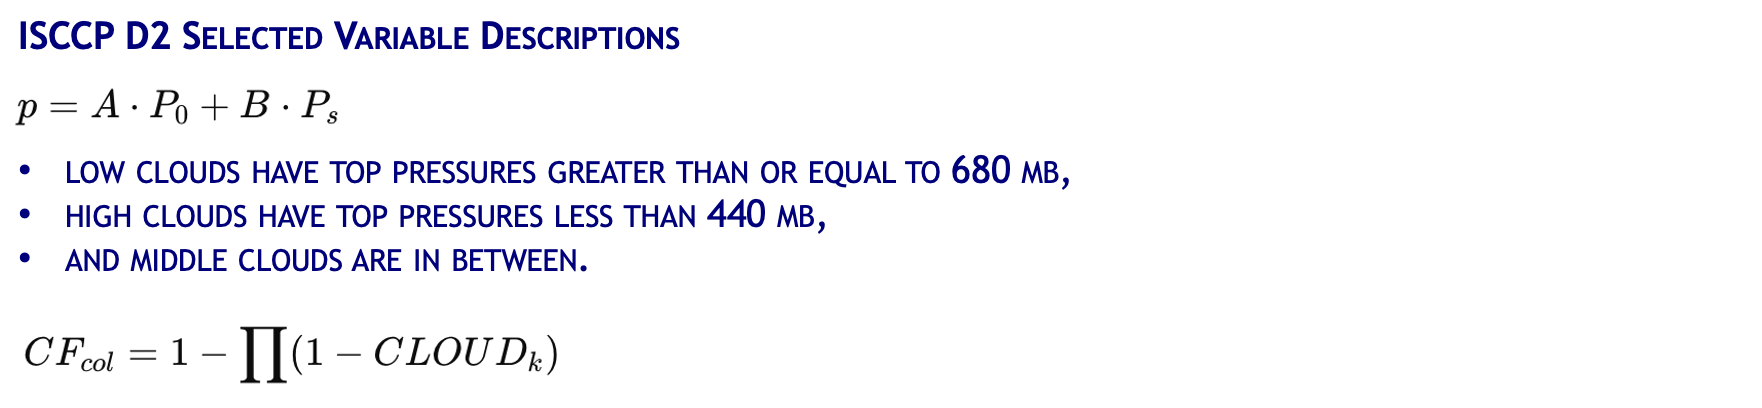

In [ ]:
# ======================
# pressure at model mid-levels (Pa)
# p = hyam * P0 + hybm * PS
# ======================
p10 = ds10_2d["hyam"] * ds10_2d["P0"] + ds10_2d["hybm"] * ds10_2d["PS"]
p4  = ds4_2d["hyam"]  * ds4_2d["P0"]  + ds4_2d["hybm"]  * ds4_2d["PS"]

# convert to hPa
p10 = p10 / 100
p4  = p4  / 100

# ======================
# cloud fraction by layer group
# ======================
def layer_cf(cloud, p, pmin=None, pmax=None):
    m = xr.ones_like(p, dtype=bool)
    if pmin is not None: m = m & (p >= pmin)
    if pmax is not None: m = m & (p <  pmax)
    c = cloud.where(m, 0)
    return 1 - (1 - c).prod("lev")

low10  = layer_cf(ds10_2d["CLOUD"], p10, pmin=680).mean("time")
mid10  = layer_cf(ds10_2d["CLOUD"], p10, pmin=440, pmax=680).mean("time")
high10 = layer_cf(ds10_2d["CLOUD"], p10, pmax=440).mean("time")
tot10  = (1 - (1 - ds10_2d["CLOUD"]).prod("lev")).mean("time")

low4   = layer_cf(ds4_2d["CLOUD"], p4, pmin=680).mean("time")
mid4   = layer_cf(ds4_2d["CLOUD"], p4, pmin=440, pmax=680).mean("time")
high4  = layer_cf(ds4_2d["CLOUD"], p4, pmax=440).mean("time")
tot4   = (1 - (1 - ds4_2d["CLOUD"]).prod("lev")).mean("time")

dlow, dmid, dhigh, dtot = low10-low4, mid10-mid4, high10-high4, tot10-tot4

lon, lat = ds10_2d["lon"], ds10_2d["lat"]
proj = ccrs.Robinson(central_longitude=0)

v = 1.0
vd = 0.01


In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(12, 12), subplot_kw={"projection": proj}, dpi=dpi)

for a in ax.ravel():
    a.coastlines(linewidth=0.8, resolution="110m")
    a.set_global()

plot_data = [
    (low10,  "Low cloud fraction (MAM10)",  "YlGnBu_r", 0, v,  "fraction"),
    (low4,   "Low cloud fraction (MAM4)",   "YlGnBu_r", 0, v,  "fraction"),
    (dlow,   "Low cloud fraction (MAM10-MAM4)", "RdBu", -vd, vd, "difference"),

    (mid10,  "Mid cloud fraction (MAM10)",  "YlGnBu_r", 0, v,  "fraction"),
    (mid4,   "Mid cloud fraction (MAM4)",   "YlGnBu_r", 0, v,  "fraction"),
    (dmid,   "Mid cloud fraction (MAM10-MAM4)", "RdBu", -vd, vd, "difference"),

    (high10, "High cloud fraction (MAM10)", "YlGnBu_r", 0, v,  "fraction"),
    (high4,  "High cloud fraction (MAM4)",  "YlGnBu_r", 0, v,  "fraction"),
    (dhigh,  "High cloud fraction (MAM10-MAM4)", "RdBu", -vd, vd, "difference"),

    (tot10,  "Total cloud fraction (MAM10)", "YlGnBu_r", 0, v,  "fraction"),
    (tot4,   "Total cloud fraction (MAM4)",  "YlGnBu_r", 0, v,  "fraction"),
    (dtot,   "Total cloud fraction (MAM10-MAM4)", "RdBu", -vd, vd, "difference"),
]

for a, (data, title, cmap, vmin, vmax, cblab) in zip(ax.ravel(), plot_data):
    im = a.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                      cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    a.set_title(title, fontsize=10)
    cb = plt.colorbar(im, ax=a, orientation="horizontal", pad=0.04, shrink=0.72, aspect=28)
    cb.set_label(cblab, fontsize=8)

plt.tight_layout()
plt.show()

### cloud fraction break down to season 

In [ ]:
# ======================
# pressure at model mid-levels (hPa)
# ======================
p10 = (ds10_2d["hyam"] * ds10_2d["P0"] + ds10_2d["hybm"] * ds10_2d["PS"]) / 100
p4  = (ds4_2d["hyam"]  * ds4_2d["P0"]  + ds4_2d["hybm"]  * ds4_2d["PS"]) / 100

# ======================
# cloud fraction by layer group
# ======================
def layer_cf(cloud, p, pmin=None, pmax=None):
    m = xr.ones_like(p, dtype=bool)
    if pmin is not None: m = m & (p >= pmin)
    if pmax is not None: m = m & (p < pmax)
    return 1 - (1 - cloud.where(m, 0)).prod("lev")

# ======================
# precompute 3D column CF
# ======================
low10_all  = layer_cf(ds10_2d["CLOUD"], p10, pmin=680)
mid10_all  = layer_cf(ds10_2d["CLOUD"], p10, pmin=440, pmax=680)
high10_all = layer_cf(ds10_2d["CLOUD"], p10, pmax=440)
tot10_all  = 1 - (1 - ds10_2d["CLOUD"]).prod("lev")

low4_all   = layer_cf(ds4_2d["CLOUD"], p4, pmin=680)
mid4_all   = layer_cf(ds4_2d["CLOUD"], p4, pmin=440, pmax=680)
high4_all  = layer_cf(ds4_2d["CLOUD"], p4, pmax=440)
tot4_all   = 1 - (1 - ds4_2d["CLOUD"]).prod("lev")

lon, lat = ds10_2d["lon"], ds10_2d["lat"]
proj = ccrs.Robinson(central_longitude=0)

v, vd = 1.0, 0.01
seasons = ["DJF", "MAM", "JJA", "SON"]

for ss in seasons:
    low10, mid10, high10, tot10 = [x.where(x["time"].dt.season == ss, drop=True).mean("time")
                                   for x in [low10_all, mid10_all, high10_all, tot10_all]]
    low4, mid4, high4, tot4 = [x.where(x["time"].dt.season == ss, drop=True).mean("time")
                               for x in [low4_all, mid4_all, high4_all, tot4_all]]
    dlow, dmid, dhigh, dtot = low10-low4, mid10-mid4, high10-high4, tot10-tot4

    fig, ax = plt.subplots(4, 3, figsize=(12, 12), subplot_kw={"projection": proj}, dpi=dpi)

    for a in ax.ravel():
        a.coastlines(linewidth=0.8, resolution="110m")
        a.set_global()

    plot_data = [
        (low10,  f"Low cloud fraction (MAM10, {ss})",  "YlGnBu_r", 0, v,  "fraction"),
        (low4,   f"Low cloud fraction (MAM4, {ss})",   "YlGnBu_r", 0, v,  "fraction"),
        (dlow,   f"Low cloud fraction (MAM10-MAM4, {ss})", "RdBu", -vd, vd, "difference"),

        (mid10,  f"Mid cloud fraction (MAM10, {ss})",  "YlGnBu_r", 0, v,  "fraction"),
        (mid4,   f"Mid cloud fraction (MAM4, {ss})",   "YlGnBu_r", 0, v,  "fraction"),
        (dmid,   f"Mid cloud fraction (MAM10-MAM4, {ss})", "RdBu", -vd, vd, "difference"),

        (high10, f"High cloud fraction (MAM10, {ss})", "YlGnBu_r", 0, v,  "fraction"),
        (high4,  f"High cloud fraction (MAM4, {ss})",  "YlGnBu_r", 0, v,  "fraction"),
        (dhigh,  f"High cloud fraction (MAM10-MAM4, {ss})", "RdBu", -vd, vd, "difference"),

        (tot10,  f"Total cloud fraction (MAM10, {ss})", "YlGnBu_r", 0, v,  "fraction"),
        (tot4,   f"Total cloud fraction (MAM4, {ss})",  "YlGnBu_r", 0, v,  "fraction"),
        (dtot,   f"Total cloud fraction (MAM10-MAM4, {ss})", "RdBu", -vd, vd, "difference"),
    ]

    for a, (data, title, cmap, vmin, vmax, cblab) in zip(ax.ravel(), plot_data):
        im = a.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                          cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
        a.set_title(title, fontsize=10)
        cb = plt.colorbar(im, ax=a, orientation="horizontal", pad=0.04, shrink=0.72, aspect=28)
        cb.set_label(cblab, fontsize=8)

    plt.tight_layout()
    plt.show()

### vertical cloud fraction

In [ ]:
ds10_2d = ds10_2d.assign_coords(lon=((ds10_2d["lon"] + 180) % 360) - 180).sortby("lon")
ds4_2d  = ds4_2d.assign_coords(lon=((ds4_2d["lon"]  + 180) % 360) - 180).sortby("lon")

cf10_lon, cf4_lon = ds10_2d["CLOUD"].mean(["time","lat"]), ds4_2d["CLOUD"].mean(["time","lat"])
cf10_lat, cf4_lat = ds10_2d["CLOUD"].mean(["time","lon"]), ds4_2d["CLOUD"].mean(["time","lon"])
dcf_lon, dcf_lat = cf10_lon - cf4_lon, cf10_lat - cf4_lat

lon, lat, lev = ds10_2d["lon"], ds10_2d["lat"], ds10_2d["lev"]

fig, ax = plt.subplots(2, 3, figsize=(12, 6), dpi=dpi)

v, vd = 0.4, 0.005
plot_data = [
    (cf10_lon, lon, "MAM10 cloud fraction", "YlGnBu_r", 0, v, "Cloud fraction"),
    (cf4_lon , lon, "MAM4 cloud fraction",  "YlGnBu_r", 0, v, "Cloud fraction"),
    (dcf_lon , lon, "MAM10 - MAM4",         "RdBu_r", -vd, vd, "Difference"),
    (cf10_lat, lat, "MAM10 cloud fraction", "YlGnBu_r", 0, v, "Cloud fraction"),
    (cf4_lat , lat, "MAM4 cloud fraction",  "YlGnBu_r", 0, v, "Cloud fraction"),
    (dcf_lat , lat, "MAM10 - MAM4",         "RdBu_r", -vd, vd, "Difference"),
]

for a, (data, x, title, cmap, vmin, vmax, cblab) in zip(ax.ravel(), plot_data):
    im = a.pcolormesh(x, lev, data, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    a.invert_yaxis(); a.set_title(title, fontsize=10); a.set_ylabel("Pressure (hPa)"); a.grid(alpha=0.3, ls="--")
    plt.colorbar(im, ax=a, pad=0.02, shrink=0.9, aspect=25).set_label(cblab, fontsize=8)

for a, xl, xlim in zip([*ax[0], *ax[1]], ["Longitude"]*3 + ["Latitude"]*3, [(-180,180)]*3 + [(-90,90)]*3):
    a.set_xlabel(xl); a.set_xlim(*xlim)

plt.tight_layout()
plt.show()

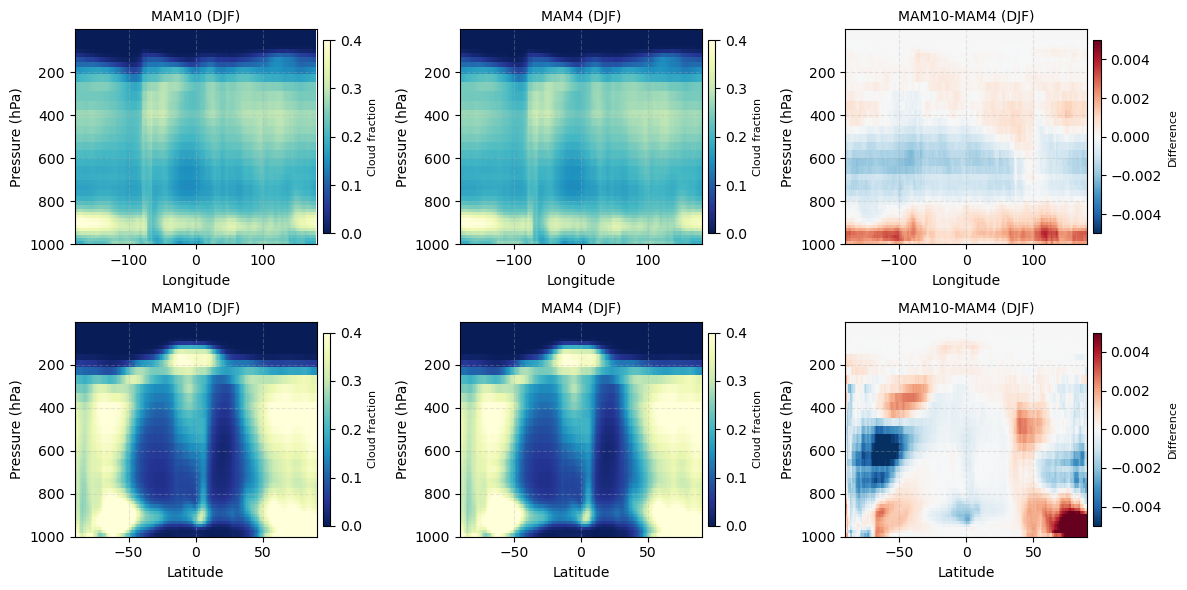

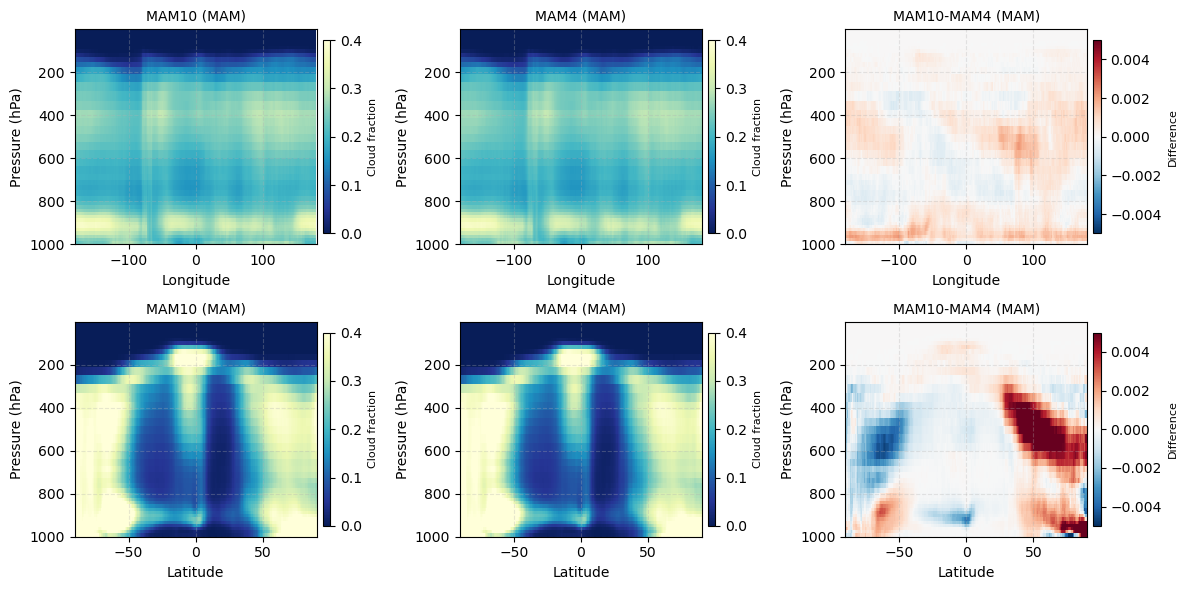

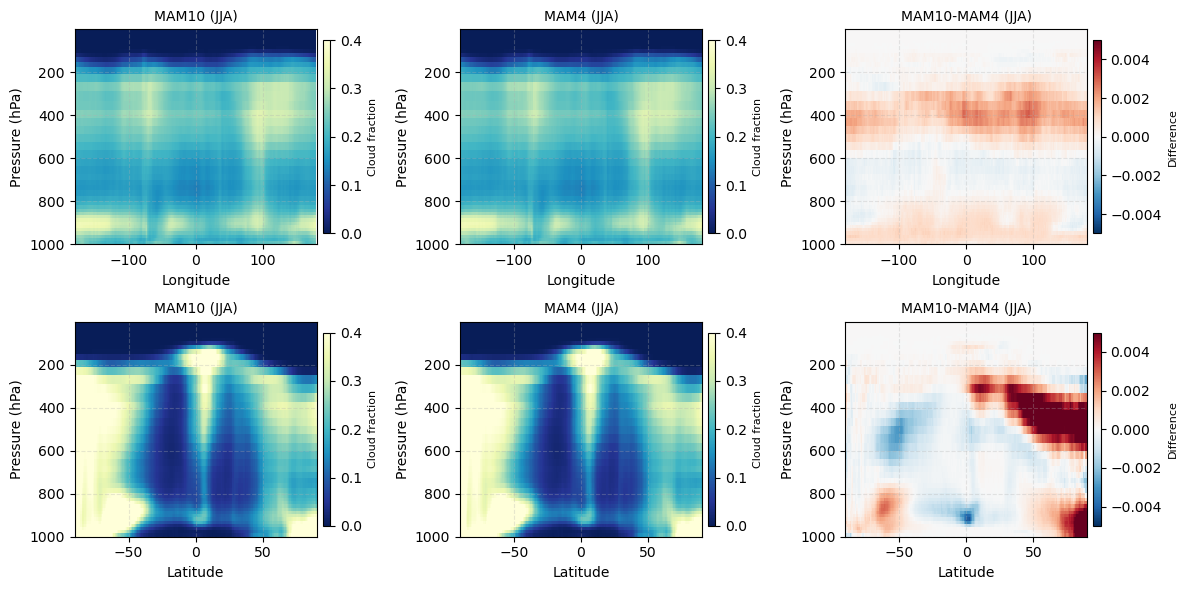

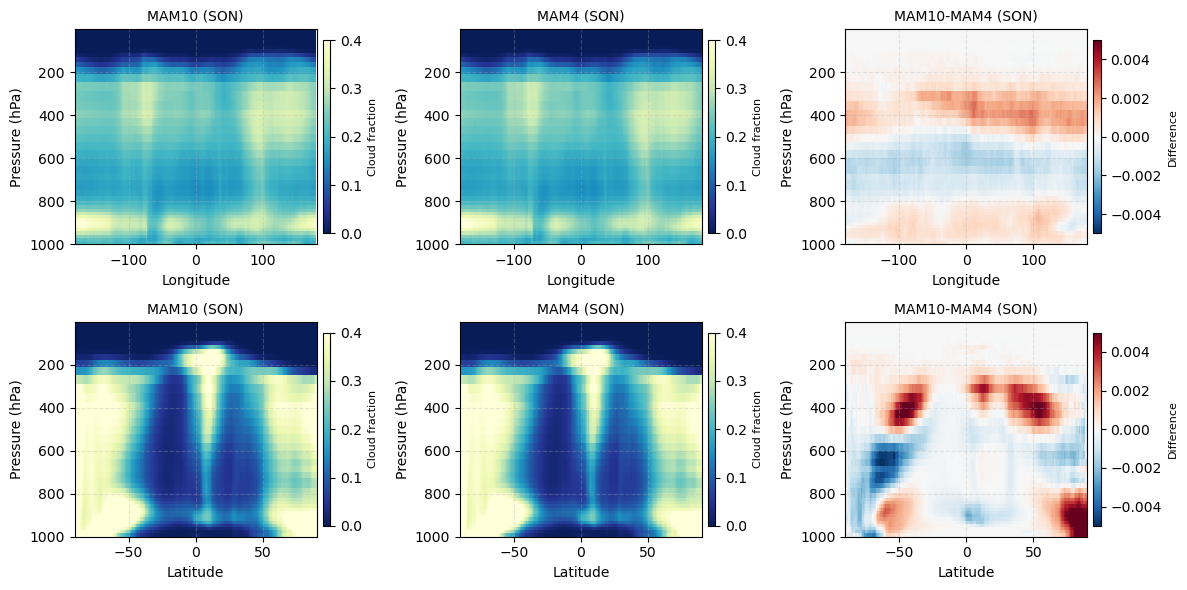

In [12]:
# ======================
# lon convert
# ======================
ds10_2d = ds10_2d.assign_coords(lon=((ds10_2d["lon"] + 180) % 360) - 180).sortby("lon")
ds4_2d  = ds4_2d.assign_coords(lon=((ds4_2d["lon"]  + 180) % 360) - 180).sortby("lon")

lon, lat, lev = ds10_2d["lon"], ds10_2d["lat"], ds10_2d["lev"]

seasons = ["DJF","MAM","JJA","SON"]
v, vd = 0.4, 0.005

for ss in seasons:

    # ===== seasonal mean =====
    cf10_lon = ds10_2d["CLOUD"].where(ds10_2d["time"].dt.season==ss, drop=True).mean(["time","lat"])
    cf4_lon  = ds4_2d["CLOUD"].where(ds4_2d["time"].dt.season==ss,  drop=True).mean(["time","lat"])
    dcf_lon  = cf10_lon - cf4_lon

    cf10_lat = ds10_2d["CLOUD"].where(ds10_2d["time"].dt.season==ss, drop=True).mean(["time","lon"])
    cf4_lat  = ds4_2d["CLOUD"].where(ds4_2d["time"].dt.season==ss,  drop=True).mean(["time","lon"])
    dcf_lat  = cf10_lat - cf4_lat

    # ===== plot =====
    fig, ax = plt.subplots(2, 3, figsize=(12, 6), dpi=dpi)

    plot_data = [
        (cf10_lon, lon, f"MAM10 ({ss})", "YlGnBu_r", 0, v, "Cloud fraction"),
        (cf4_lon , lon, f"MAM4 ({ss})",  "YlGnBu_r", 0, v, "Cloud fraction"),
        (dcf_lon , lon, f"MAM10-MAM4 ({ss})", "RdBu_r", -vd, vd, "Difference"),
        (cf10_lat, lat, f"MAM10 ({ss})", "YlGnBu_r", 0, v, "Cloud fraction"),
        (cf4_lat , lat, f"MAM4 ({ss})",  "YlGnBu_r", 0, v, "Cloud fraction"),
        (dcf_lat , lat, f"MAM10-MAM4 ({ss})", "RdBu_r", -vd, vd, "Difference"),
    ]

    for a, (data, x, title, cmap, vmin, vmax, cblab) in zip(ax.ravel(), plot_data):
        im = a.pcolormesh(x, lev, data, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
        a.invert_yaxis(); a.set_title(title, fontsize=10)
        a.set_ylabel("Pressure (hPa)"); a.grid(alpha=0.3, ls="--")
        plt.colorbar(im, ax=a, pad=0.02, shrink=0.9, aspect=25).set_label(cblab, fontsize=8)

    for a, xl, xlim in zip([*ax[0], *ax[1]], ["Longitude"]*3+["Latitude"]*3, [(-180,180)]*3+[(-90,90)]*3):
        a.set_xlabel(xl); a.set_xlim(*xlim)

    # fig.suptitle(f"{ss} Cloud Vertical Profile", fontsize=14)
    plt.tight_layout()
    plt.show()

### Cloud fraction time series

NameError: name 'low10_all' is not defined

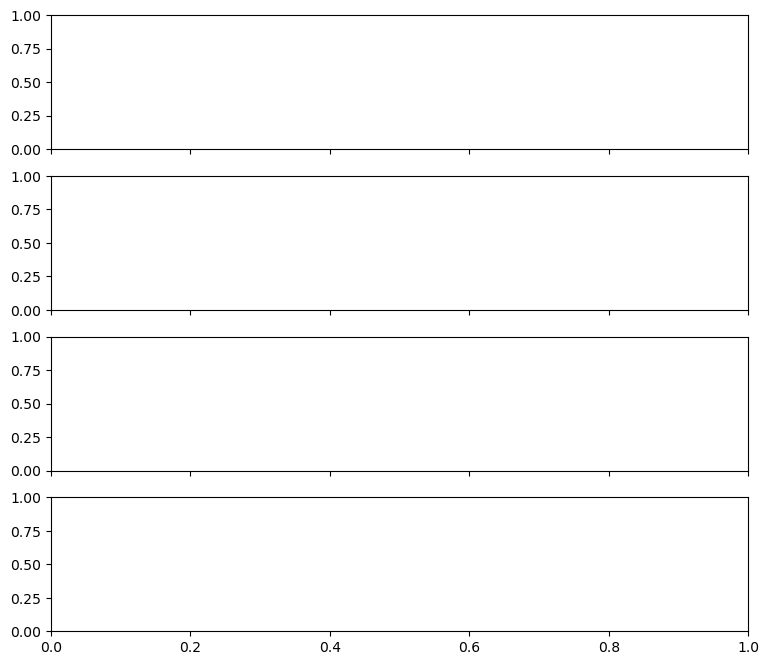

In [13]:
import pandas as pd
fig, ax = plt.subplots(4, 1, figsize=(9, 8), dpi=dpi, sharex=True)

# ===== global mean =====
low10_ts  = low10_all.mean(["lat","lon"])
mid10_ts  = mid10_all.mean(["lat","lon"])
high10_ts = high10_all.mean(["lat","lon"])
tot10_ts  = tot10_all.mean(["lat","lon"])

low4_ts  = low4_all.mean(["lat","lon"])
mid4_ts  = mid4_all.mean(["lat","lon"])
high4_ts = high4_all.mean(["lat","lon"])
tot4_ts  = tot4_all.mean(["lat","lon"])

dlow_ts  = low10_ts  - low4_ts
dmid_ts  = mid10_ts  - mid4_ts
dhigh_ts = high10_ts - high4_ts
dtot_ts  = tot10_ts  - tot4_ts

time = pd.to_datetime([str(t) for t in low10_ts["time"].values])

# ======================
# plotting
# ======================
series = [
    (low10_ts,  low4_ts,  dlow_ts,  "Low cloud fraction"),
    (mid10_ts,  mid4_ts,  dmid_ts,  "Mid cloud fraction"),
    (high10_ts, high4_ts, dhigh_ts, "High cloud fraction"),
    (tot10_ts,  tot4_ts,  dtot_ts,  "Total cloud fraction"),
]

for i, (s10, s4, ds, title) in enumerate(series):
    ax2 = ax[i].twinx()

    ax[i].plot(time, s10.values, color="firebrick", lw=1.5, label="MAM10")
    ax[i].plot(time, s4.values,  color="navy", lw=1.5, ls="--", label="MAM4")
    ax2.plot(time, ds.values, color="k", lw=2.5, label="MAM10-MAM4")
    ax2.axhline(0, color="k", lw=1,)

    ax[i].set_ylabel("CF")
    ax2.set_ylabel("ΔCF")
    ax[i].set_title(title)
    ax[i].grid(alpha=0.3, ls="--")

    lines = ax[i].get_lines() + ax2.get_lines()
    lines = [l for l in lines if not l.get_label().startswith('_')]
    labels = [l.get_label() for l in lines]
    ax[0].legend(lines, labels, fontsize=8, loc="upper right")

ax[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

## LWP

In [ ]:
lwp10_all = ds10_2d["TGCLDLWP"] * 1e3   # g m^-2
lwp4_all  = ds4_2d["TGCLDLWP"]  * 1e3

lon, lat = ds10_2d["lon"], ds10_2d["lat"]
proj = ccrs.Robinson(central_longitude=0)

seasons = ["ANN", "DJF", "MAM", "JJA", "SON"]
v, vd = 250, 20

fig, ax = plt.subplots(len(seasons), 3, figsize=(12, 14), subplot_kw={"projection": proj}, dpi=dpi)

for a in ax.ravel():
    a.coastlines(linewidth=0.8, resolution="110m")
    a.set_global()

for i, ss in enumerate(seasons):
    if ss == "ANN":
        lwp10 = lwp10_all.mean("time")
        lwp4  = lwp4_all.mean("time")
    else:
        lwp10 = lwp10_all.where(lwp10_all["time"].dt.season == ss, drop=True).mean("time")
        lwp4  = lwp4_all.where(lwp4_all["time"].dt.season == ss, drop=True).mean("time")

    dlwp = lwp10 - lwp4

    row_data = [
        (lwp10, f"MAM10 ({ss})", "Blues", 0, v, "g m$^{-2}$"),
        (lwp4,  f"MAM4 ({ss})",  "Blues", 0, v, "g m$^{-2}$"),
        (dlwp,  f"MAM10-MAM4 ({ss})", "RdBu_r", -vd, vd, "Difference, g m$^{-2}$"),
    ]

    for j, (data, title, cmap, vmin, vmax, cblab) in enumerate(row_data):
        im = ax[i, j].pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                                 cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
        ax[i, j].set_title(title, fontsize=10)
        cb = plt.colorbar(im, ax=ax[i, j], orientation="horizontal", pad=0.04, shrink=0.72, aspect=28)
        cb.set_label(cblab, fontsize=8)

plt.tight_layout()
plt.show()

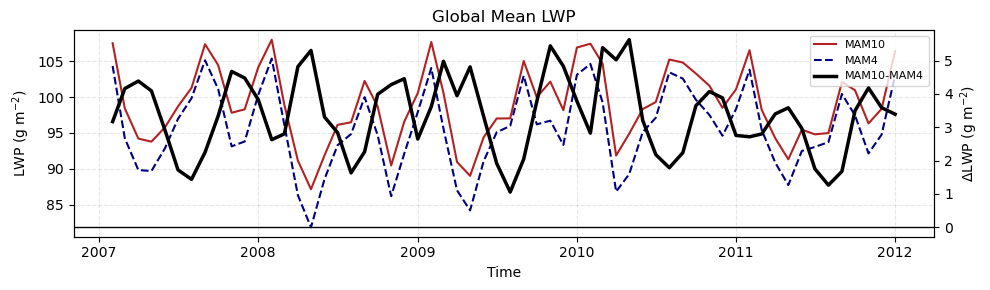

In [14]:
lwp10 = (ds10_2d["TGCLDLWP"]*1e3).mean(["lat","lon"])
lwp4  = (ds4_2d["TGCLDLWP"]*1e3).mean(["lat","lon"])
dlwp  = lwp10 - lwp4
time  = pd.to_datetime([str(t) for t in lwp10["time"].values])

fig, ax = plt.subplots(1,1,figsize=(10,3),dpi=dpi)
ax2 = ax.twinx()

ax.plot(time,lwp10.values,color="firebrick",lw=1.5,label="MAM10")
ax.plot(time,lwp4.values,color="navy",lw=1.5,ls="--",label="MAM4")
ax2.plot(time,dlwp.values,color="k",lw=2.5,label="MAM10-MAM4")
ax2.axhline(0,color="k",lw=1,label="_nolegend_")

ax.set_ylabel("LWP (g m$^{-2}$)")
ax2.set_ylabel("ΔLWP (g m$^{-2}$)")
ax.set_title("Global Mean LWP")
ax.grid(alpha=0.3,ls="--")

lines=[l for l in ax.get_lines()+ax2.get_lines() if not l.get_label().startswith("_")]
ax.legend(lines,[l.get_label() for l in lines],fontsize=8,loc="upper right")

ax.set_xlabel("Time")
plt.tight_layout()
plt.show()

## IWP

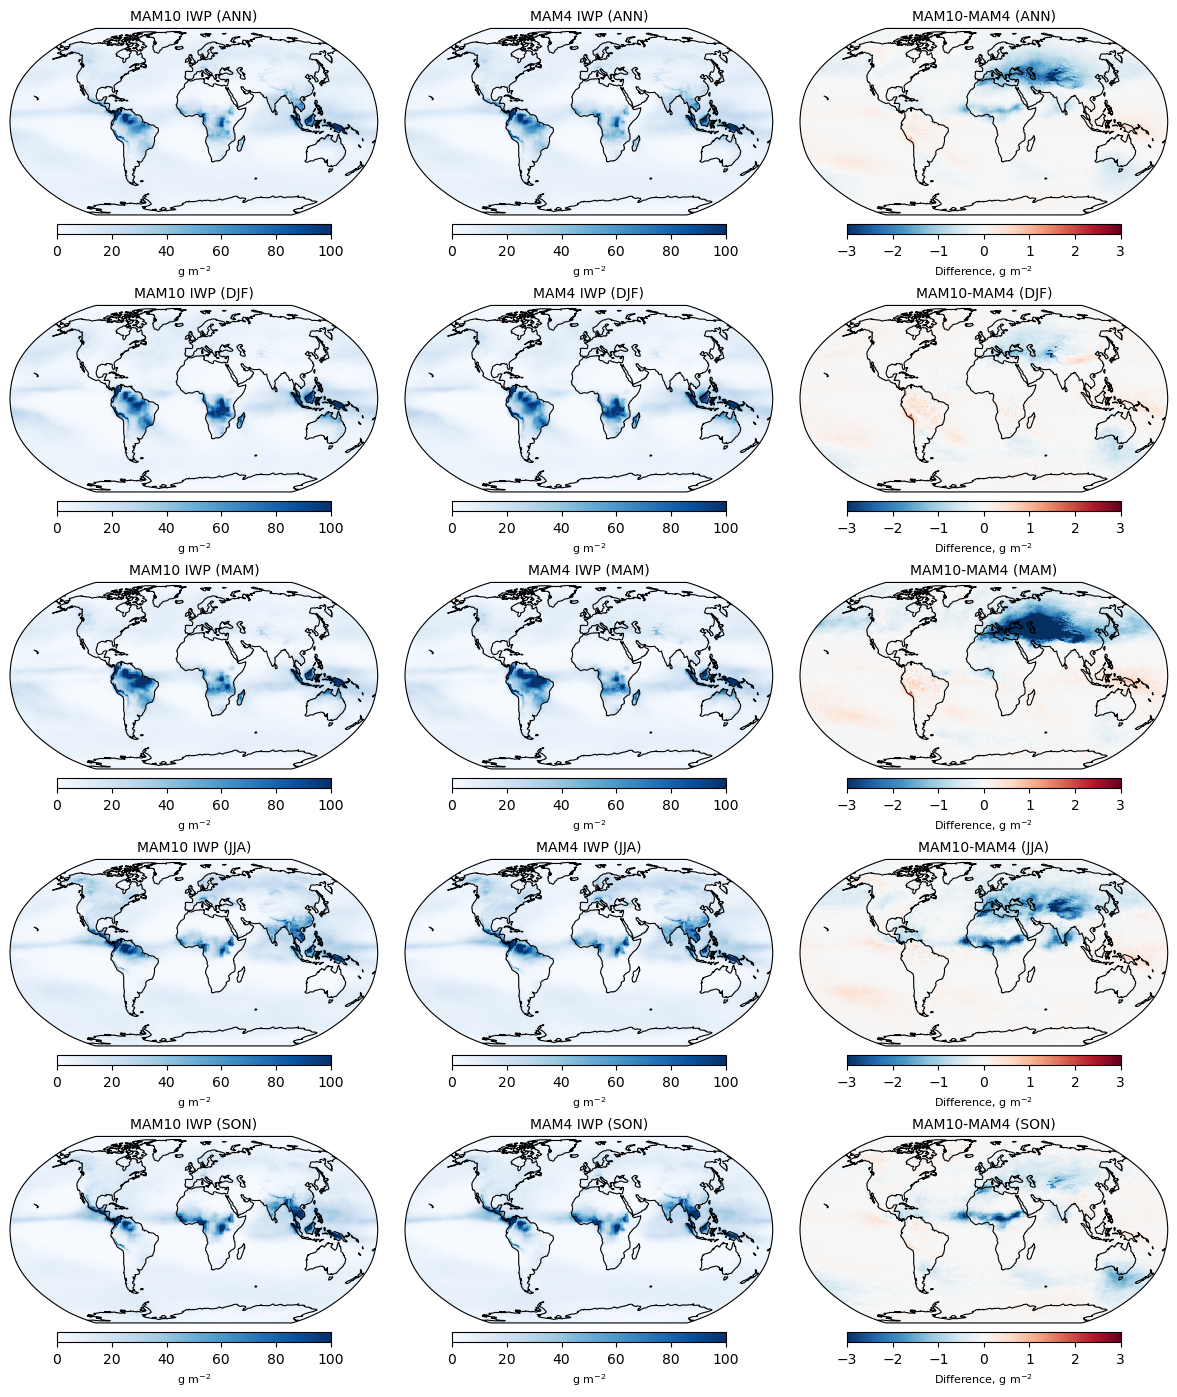

In [15]:
iwp10_all = (ds10_2d["TGCLDCWP"] - ds10_2d["TGCLDLWP"]) * 1e3
iwp4_all  = (ds4_2d["TGCLDCWP"]  - ds4_2d["TGCLDLWP"])  * 1e3

lon, lat = ds10_2d["lon"], ds10_2d["lat"]
proj = ccrs.Robinson(central_longitude=0)

seasons = ["ANN","DJF","MAM","JJA","SON"]
v, vd = 100, 3

fig, ax = plt.subplots(len(seasons), 3, figsize=(12, 14), subplot_kw={"projection": proj}, dpi=dpi)

for a in ax.ravel():
    a.coastlines(linewidth=0.8, resolution="110m")
    a.set_global()

for i, ss in enumerate(seasons):
    if ss == "ANN":
        iwp10 = iwp10_all.mean("time")
        iwp4  = iwp4_all.mean("time")
    else:
        iwp10 = iwp10_all.where(iwp10_all["time"].dt.season==ss, drop=True).mean("time")
        iwp4  = iwp4_all.where(iwp4_all["time"].dt.season==ss,  drop=True).mean("time")

    diwp = iwp10 - iwp4

    row = [
        (iwp10, f"MAM10 IWP ({ss})", "Blues", 0, v,  "g m$^{-2}$"),
        (iwp4 , f"MAM4 IWP ({ss})",  "Blues", 0, v,  "g m$^{-2}$"),
        (diwp , f"MAM10-MAM4 ({ss})","RdBu_r", -vd, vd, "Difference, g m$^{-2}$"),
    ]

    for j, (data, title, cmap, vmin, vmax, cblab) in enumerate(row):
        im = ax[i,j].pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                               cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
        ax[i,j].set_title(title, fontsize=10)
        plt.colorbar(im, ax=ax[i,j], orientation="horizontal", pad=0.04, shrink=0.72, aspect=28).set_label(cblab, fontsize=8)

plt.tight_layout()
plt.show()

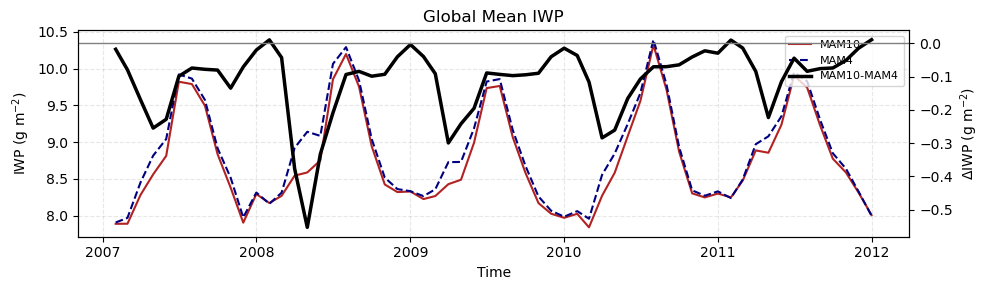

In [16]:
iwp10 = (ds10_2d["TGCLDCWP"] - ds10_2d["TGCLDLWP"]) * 1e3
iwp4  = (ds4_2d["TGCLDCWP"]  - ds4_2d["TGCLDLWP"])  * 1e3

iwp10_ts = iwp10.mean(["lat","lon"])
iwp4_ts  = iwp4.mean(["lat","lon"])
diwp_ts  = iwp10_ts - iwp4_ts

time = pd.to_datetime([str(t) for t in iwp10_ts["time"].values])

fig, ax = plt.subplots(1,1,figsize=(10,3),dpi=dpi)
ax2 = ax.twinx()

ax.plot(time,iwp10_ts.values,color="firebrick",lw=1.5,label="MAM10")
ax.plot(time,iwp4_ts.values,color="navy",lw=1.5,ls="--",label="MAM4")
ax2.plot(time,diwp_ts.values,color="k",lw=2.5,label="MAM10-MAM4")
ax2.axhline(0,color="gray",lw=1,label="_nolegend_")

ax.set_ylabel("IWP (g m$^{-2}$)")
ax2.set_ylabel("ΔIWP (g m$^{-2}$)")
ax.set_title("Global Mean IWP")
ax.grid(alpha=0.3,ls="--")

lines=[l for l in ax.get_lines()+ax2.get_lines() if not l.get_label().startswith("_")]
ax.legend(lines,[l.get_label() for l in lines],fontsize=8,loc="upper right")

ax.set_xlabel("Time")
plt.tight_layout()
plt.show()